# Inference → flags.txt format

Carga ambos checkpoints, muestra su output raw, y normaliza a `output_raw.json`.

| Modelo | Output raw | Cobertura flags.txt |
|---|---|---|
| ResNet-18 | 15 probs binarias (CelebA) | ~9/17 categorías (mapeo aprox.) |
| ViT Multihead | 17 categorías directas | 17/17 ✓ |

Imagen: 000001.jpg  |  Device: mps


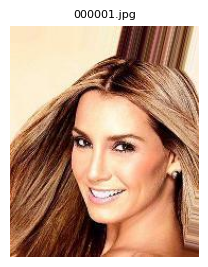

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import json
import timm
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2

from pet_gen.models.feature_model import FacialFeatureModel

DEVICE   = 'mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu')
CKPT_DIR = Path('../checkpoints')
DATA_DIR  = Path('../data/celeba/img_align_celeba')

# Categorías y clases válidas (flags.txt)
CLASS_LABELS = {
    'color_pelo':    ['negro', 'castano', 'rubio', 'pelirrojo', 'gris', 'calvo'],
    'textura_pelo':  ['liso', 'ondulado', 'rizado', 'muy_rizado'],
    'longitud_pelo': ['corto', 'medio', 'largo', 'calvo'],
    'cejas':         ['normales', 'arqueadas', 'pobladas', 'finas', 'rectas'],
    'forma_ojos':    ['almendrada', 'redonda', 'rasgada', 'caida', 'prominente'],
    'tamano_nariz':  ['pequena', 'mediana', 'grande'],
    'forma_nariz':   ['recta', 'aguileña', 'respingona', 'ancha'],
    'grosor_labios': ['finos', 'medianos', 'carnosos'],
    'pomulos':       ['planos', 'normales', 'altos', 'prominentes'],
    'mandibula':     ['suave', 'marcada', 'ancha', 'estrecha'],
    'barbilla':      ['redonda', 'puntiaguda', 'cuadrada', 'hendida'],
    'forma_cara':    ['oval', 'redonda', 'cuadrada', 'corazon', 'diamante', 'oblonga'],
    'vello_facial':  ['sin_barba', 'barba_corta', 'barba_larga', 'bigote'],
    'gafas':         [False, True],
    'pecas':         [False, True],
    'tono_piel':     ['muy_claro', 'claro', 'medio', 'oliva', 'bronceado', 'oscuro', 'muy_oscuro'],
    'rango_edad':    ['nino', 'joven', 'adulto', 'maduro', 'mayor'],
}

transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2(),
])

def load_image(path):
    img = np.array(Image.open(path).convert('RGB'))
    return transform(image=img)['image'].unsqueeze(0).to(DEVICE)

# ── Imagen de prueba ─────────────────────────────────────────────────────────
# Cambia esta ruta a tu foto
TEST_IMAGE = sorted(DATA_DIR.glob('*.jpg'))[0] if DATA_DIR.exists() else None
# TEST_IMAGE = Path('tu_foto.jpg')

if TEST_IMAGE is None or not TEST_IMAGE.exists():
    raise FileNotFoundError('Pon la ruta a tu imagen en TEST_IMAGE')

img_tensor = load_image(TEST_IMAGE)
print(f'Imagen: {TEST_IMAGE.name}  |  Device: {DEVICE}')
plt.figure(figsize=(3,3))
plt.imshow(Image.open(TEST_IMAGE))
plt.axis('off'); plt.title(TEST_IMAGE.name, fontsize=8); plt.show()

---
## Carga de modelo 1 — ResNet-18: output raw

ResNet-18 cargado — época 19  mAP=0.7530

── Output raw (prob por atributo) ──
{
  "Black_Hair": 0.0001,
  "Blond_Hair": 0.0506,
  "Brown_Hair": 0.913,
  "Gray_Hair": 0.0,
  "Straight_Hair": 0.6715,
  "Wavy_Hair": 0.5076,
  "Arched_Eyebrows": 0.5737,
  "Bushy_Eyebrows": 0.132,
  "Narrow_Eyes": 0.4034,
  "Big_Nose": 0.0008,
  "Pointy_Nose": 0.9466,
  "High_Cheekbones": 0.9331,
  "Oval_Face": 0.1237,
  "Pale_Skin": 0.0005,
  "Chubby": 0.0
}

Embedding shape: (256,)  norm: 32.119


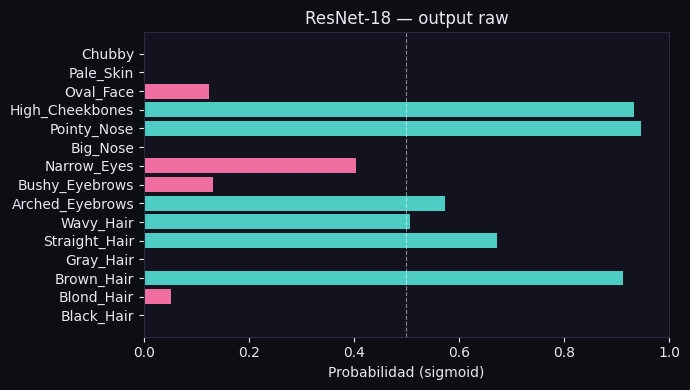

In [2]:
RESNET_ATTRS = [
    'Black_Hair', 'Blond_Hair', 'Brown_Hair', 'Gray_Hair',
    'Straight_Hair', 'Wavy_Hair', 'Arched_Eyebrows', 'Bushy_Eyebrows',
    'Narrow_Eyes', 'Big_Nose', 'Pointy_Nose', 'High_Cheekbones',
    'Oval_Face', 'Pale_Skin', 'Chubby',
]

# Cargar checkpoint
resnet_ckpt  = torch.load(CKPT_DIR / 'resnet-18.pt', map_location='cpu', weights_only=False)
resnet_model = FacialFeatureModel(backbone_name='resnet18', pretrained=False,
                                   embedding_dim=256, num_attributes=15)
resnet_model.load_state_dict(resnet_ckpt['model_state_dict'])
resnet_model = resnet_model.to(DEVICE).eval()
print(f'ResNet-18 cargado — época {resnet_ckpt["epoch"]}  mAP={resnet_ckpt["metrics"]["mAP"]:.4f}')

# Inferencia
with torch.no_grad():
    resnet_out = resnet_model(img_tensor)

resnet_logits = resnet_out['logits'][0].cpu().numpy()
resnet_probs  = 1.0 / (1.0 + np.exp(-resnet_logits))
resnet_embed  = resnet_out['embedding'][0].cpu().numpy()

# Output raw
resnet_raw = {attr: round(float(prob), 4) for attr, prob in zip(RESNET_ATTRS, resnet_probs)}
print('\n── Output raw (prob por atributo) ──')
print(json.dumps(resnet_raw, indent=2))
print(f'\nEmbedding shape: {resnet_embed.shape}  norm: {np.linalg.norm(resnet_embed):.3f}')

# Plot
fig, ax = plt.subplots(figsize=(7, 4))
fig.patch.set_facecolor('#0d0d14'); ax.set_facecolor('#13131f')
colors = ['#4ecdc4' if p >= 0.5 else '#f06fa0' for p in resnet_probs]
ax.barh(RESNET_ATTRS, resnet_probs, color=colors)
ax.axvline(0.5, color='white', linestyle='--', lw=0.8, alpha=0.5)
ax.set_xlim(0, 1); ax.set_xlabel('Probabilidad (sigmoid)', color='#e8e8f0')
ax.set_title('ResNet-18 — output raw', color='#e8e8f0')
ax.tick_params(colors='#e8e8f0')
for s in ax.spines.values(): s.set_edgecolor('#2a2a45')
plt.tight_layout(); plt.show()

---
## Carga el modelo 2 — ViT Multihead: output raw

ViT Multihead cargado — época 9  val_loss=4.5366

── Output raw (softmax por categoría) ──
{
  "color_pelo": {
    "negro": 0.0742,
    "castano": 0.913,
    "rubio": 0.0127,
    "pelirrojo": 0.0,
    "gris": 0.0,
    "calvo": 0.0
  },
  "textura_pelo": {
    "liso": 0.589,
    "ondulado": 0.411,
    "rizado": 0.0,
    "muy_rizado": 0.0
  },
  "longitud_pelo": {
    "corto": 0.0,
    "medio": 1.0,
    "largo": 0.0,
    "calvo": 0.0
  },
  "cejas": {
    "normales": 0.2466,
    "arqueadas": 0.7528,
    "pobladas": 0.0006,
    "finas": 0.0,
    "rectas": 0.0
  },
  "forma_ojos": {
    "almendrada": 0.9814,
    "redonda": 0.0,
    "rasgada": 0.0184,
    "caida": 0.0001,
    "prominente": 0.0
  },
  "tamano_nariz": {
    "pequena": 0.9624,
    "mediana": 0.0375,
    "grande": 0.0001
  },
  "forma_nariz": {
    "recta": 0.0377,
    "aguileña": 0.0,
    "respingona": 0.9622,
    "ancha": 0.0001
  },
  "grosor_labios": {
    "finos": 0.0,
    "medianos": 0.615,
    "carnosos": 0.385
  },
  "p

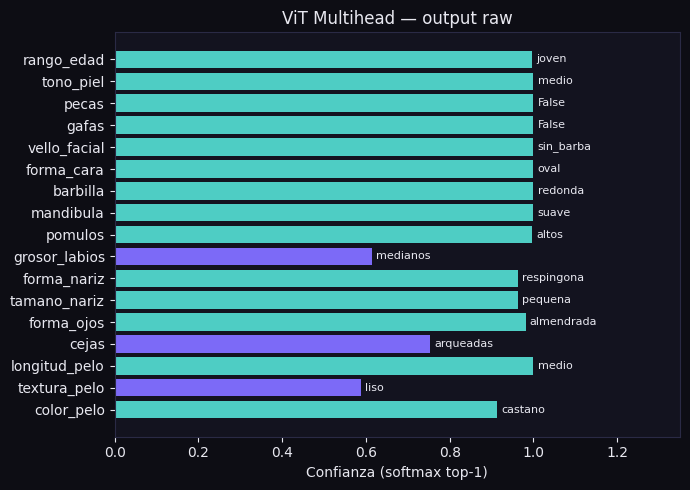

In [3]:
vit_ckpt     = torch.load(CKPT_DIR / 'vit_multihead_best.pt', map_location='cpu', weights_only=False)
VIT_LABELS   = vit_ckpt['class_labels']
VIT_LABEL2IDX = {cat: {v: i for i, v in enumerate(vals)} for cat, vals in VIT_LABELS.items()}

class ViTMultiHead(nn.Module):
    def __init__(self, class_labels, embedding_dim=256):
        super().__init__()
        self.backbone = timm.create_model('vit_base_patch16_224.augreg_in21k',
                                          pretrained=False, num_classes=0)
        vit_dim = self.backbone.num_features
        self.embedding = nn.Sequential(
            nn.Linear(vit_dim, embedding_dim), nn.ReLU(), nn.Dropout(0.3))
        self.heads = nn.ModuleDict({
            name: nn.Linear(embedding_dim, len(classes))
            for name, classes in class_labels.items()
        })
    def forward(self, x):
        feat = self.backbone(x)
        emb  = self.embedding(feat)
        return {'embedding': emb, 'logits': {n: h(emb) for n, h in self.heads.items()}}
    def unfreeze_backbone(self):
        for p in self.backbone.parameters(): p.requires_grad = True

vit_model = ViTMultiHead(VIT_LABELS)
vit_model.load_state_dict(vit_ckpt['model_state'])
vit_model = vit_model.to(DEVICE).eval()
print(f'ViT Multihead cargado — época {vit_ckpt["epoch"]}  val_loss={vit_ckpt["val_loss"]:.4f}')

# Inferencia
with torch.no_grad():
    vit_out = vit_model(img_tensor)

vit_embed = vit_out['embedding'][0].cpu().numpy()

# Output raw: por categoría → prob de cada clase
vit_raw = {}
for cat, logits in vit_out['logits'].items():
    probs = F.softmax(logits[0], dim=0).cpu().numpy()
    classes = list(VIT_LABELS[cat])
    vit_raw[cat] = {str(cls): round(float(p), 4) for cls, p in zip(classes, probs)}

print('\n── Output raw (softmax por categoría) ──')
print(json.dumps(vit_raw, indent=2, ensure_ascii=False))
print(f'\nEmbedding shape: {vit_embed.shape}  norm: {np.linalg.norm(vit_embed):.3f}')

# Plot: confianza de predicción por categoría
cats   = list(vit_raw.keys())
top_probs = [max(vit_raw[c].values()) for c in cats]
top_preds = [max(vit_raw[c], key=vit_raw[c].get) for c in cats]

fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor('#0d0d14'); ax.set_facecolor('#13131f')
colors_v = ['#4ecdc4' if p >= 0.8 else '#7c6af7' if p >= 0.5 else '#f06fa0' for p in top_probs]
bars = ax.barh(cats, top_probs, color=colors_v)
for bar, pred in zip(bars, top_preds):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            pred, va='center', fontsize=8, color='#e8e8f0')
ax.set_xlim(0, 1.35)
ax.set_xlabel('Confianza (softmax top-1)', color='#e8e8f0')
ax.set_title('ViT Multihead — output raw', color='#e8e8f0')
ax.tick_params(colors='#e8e8f0')
for s in ax.spines.values(): s.set_edgecolor('#2a2a45')
plt.tight_layout(); plt.show()

---
## Celda 3 — Normalización a output_raw.json

**Cobertura del mapeo ResNet-18 → flags.txt:**

| flags.txt | ResNet attrs usados | Cobertura |
|---|---|---|
| `color_pelo` | Black/Blond/Brown/Gray_Hair | ✓ aprox. |
| `textura_pelo` | Straight/Wavy_Hair | ✓ parcial (no rizado) |
| `longitud_pelo` | — | ✗ sin mapping |
| `cejas` | Arched/Bushy_Eyebrows | ✓ parcial |
| `forma_ojos` | Narrow_Eyes | ✓ parcial |
| `tamano_nariz` | Big_Nose | ✓ parcial |
| `forma_nariz` | Pointy_Nose | ✓ parcial |
| `grosor_labios` | — | ✗ sin mapping |
| `pomulos` | High_Cheekbones | ✓ parcial |
| `mandibula` | Chubby | ✓ aprox. |
| `barbilla` | — | ✗ sin mapping |
| `forma_cara` | Oval_Face | ✓ parcial |
| `vello_facial` | — | ✗ sin mapping |
| `gafas` | — | ✗ sin mapping |
| `pecas` | — | ✗ sin mapping |
| `tono_piel` | Pale_Skin | ✓ parcial |
| `rango_edad` | — | ✗ sin mapping |

In [4]:
def normalize_resnet_to_flags(probs_dict: dict) -> dict:
    """
    Mapea el output raw de ResNet-18 (15 probs CelebA) a flags.txt.
    Categorías sin mapping directo quedan como None.
    probs_dict: { 'Black_Hair': 0.72, 'Blond_Hair': 0.10, ... }
    """
    p = probs_dict  # alias corto

    # ── color_pelo ────────────────────────────────────────────────────────────
    hair_map = {
        'negro':   p['Black_Hair'],
        'rubio':   p['Blond_Hair'],
        'castano': p['Brown_Hair'],
        'gris':    p['Gray_Hair'],
    }
    top_hair = max(hair_map, key=hair_map.get)
    # Si ninguno supera 0.35 → ambiguo, asumimos castano
    color_pelo = top_hair if hair_map[top_hair] >= 0.35 else 'castano'

    # ── textura_pelo ──────────────────────────────────────────────────────────
    # ResNet sólo distingue liso/ondulado; rizado/muy_rizado no tienen attr
    if p['Straight_Hair'] >= 0.5:
        textura_pelo = 'liso'
    elif p['Wavy_Hair'] >= 0.5:
        textura_pelo = 'ondulado'
    elif p['Straight_Hair'] > p['Wavy_Hair']:
        textura_pelo = 'liso'
    else:
        textura_pelo = 'ondulado'

    # ── cejas ─────────────────────────────────────────────────────────────────
    if p['Bushy_Eyebrows'] >= 0.5 and p['Arched_Eyebrows'] >= 0.5:
        cejas = 'pobladas'   # ambas → pobladas es el caso más descriptivo
    elif p['Bushy_Eyebrows'] >= 0.5:
        cejas = 'pobladas'
    elif p['Arched_Eyebrows'] >= 0.5:
        cejas = 'arqueadas'
    else:
        cejas = 'normales'

    # ── forma_ojos ────────────────────────────────────────────────────────────
    if p['Narrow_Eyes'] >= 0.5:
        forma_ojos = 'rasgada'
    else:
        forma_ojos = 'almendrada'   # default más común

    # ── tamano_nariz ─────────────────────────────────────────────────────────
    if p['Big_Nose'] >= 0.5:
        tamano_nariz = 'grande'
    else:
        tamano_nariz = 'mediana'

    # ── forma_nariz ───────────────────────────────────────────────────────────
    if p['Pointy_Nose'] >= 0.5:
        forma_nariz = 'respingona'
    elif p['Big_Nose'] >= 0.5:
        forma_nariz = 'ancha'
    else:
        forma_nariz = 'recta'

    # ── pomulos ───────────────────────────────────────────────────────────────
    if p['High_Cheekbones'] >= 0.5:
        pomulos = 'altos'
    else:
        pomulos = 'normales'

    # ── mandibula ─────────────────────────────────────────────────────────────
    # Chubby implica mandíbula más ancha/suave
    if p['Chubby'] >= 0.5:
        mandibula = 'ancha'
    else:
        mandibula = 'suave'

    # ── forma_cara ────────────────────────────────────────────────────────────
    if p['Oval_Face'] >= 0.5:
        forma_cara = 'oval'
    elif p['Chubby'] >= 0.5:
        forma_cara = 'redonda'
    else:
        forma_cara = 'oval'   # default más común en CelebA

    # ── tono_piel ─────────────────────────────────────────────────────────────
    if p['Pale_Skin'] >= 0.6:
        tono_piel = 'muy_claro'
    elif p['Pale_Skin'] >= 0.4:
        tono_piel = 'claro'
    else:
        tono_piel = 'medio'   # ResNet no distingue más oscuro

    return {
        'color_pelo':    color_pelo,
        'textura_pelo':  textura_pelo,
        'longitud_pelo': None,          # sin mapping en ResNet-18
        'cejas':         cejas,
        'forma_ojos':    forma_ojos,
        'tamano_nariz':  tamano_nariz,
        'forma_nariz':   forma_nariz,
        'grosor_labios': None,          # sin mapping
        'pomulos':       pomulos,
        'mandibula':     mandibula,
        'barbilla':      None,          # sin mapping
        'forma_cara':    forma_cara,
        'vello_facial':  None,          # sin mapping
        'gafas':         'False',       # sin mapping, default
        'pecas':         'False',       # sin mapping, default
        'tono_piel':     tono_piel,
        'rango_edad':    None,          # sin mapping
    }


def normalize_vit_to_flags(vit_raw_dict: dict) -> dict:
    """
    ViT output ya tiene el formato correcto.
    Toma el top-1 de cada categoría y valida que esté en CLASS_LABELS.
    vit_raw_dict: { 'color_pelo': {'negro': 0.7, 'castano': 0.2, ...}, ... }
    """
    out = {}
    for cat, valid_vals in CLASS_LABELS.items():
        if cat not in vit_raw_dict:
            out[cat] = None
            continue
        probs_cat = vit_raw_dict[cat]
        top_val   = max(probs_cat, key=probs_cat.get)
        # Convertir booleanos guardados como string
        if valid_vals == [False, True]:
            top_val = str(top_val == 'True' or top_val is True)
        # Validar que el valor está en las clases permitidas
        valid_strs = [str(v) for v in valid_vals]
        out[cat] = top_val if top_val in valid_strs else valid_strs[0]
    return out


# ── Ejecutar normalización ────────────────────────────────────────────────────
normalized_resnet = normalize_resnet_to_flags(resnet_raw)
normalized_vit    = normalize_vit_to_flags(vit_raw)

print('══ ResNet-18 → flags.txt ══')
print(json.dumps(normalized_resnet, indent=2, ensure_ascii=False))

print('\n══ ViT Multihead → flags.txt ══')
print(json.dumps(normalized_vit, indent=2, ensure_ascii=False))

══ ResNet-18 → flags.txt ══
{
  "color_pelo": "castano",
  "textura_pelo": "liso",
  "longitud_pelo": null,
  "cejas": "arqueadas",
  "forma_ojos": "almendrada",
  "tamano_nariz": "mediana",
  "forma_nariz": "respingona",
  "grosor_labios": null,
  "pomulos": "altos",
  "mandibula": "suave",
  "barbilla": null,
  "forma_cara": "oval",
  "vello_facial": null,
  "gafas": "False",
  "pecas": "False",
  "tono_piel": "medio",
  "rango_edad": null
}

══ ViT Multihead → flags.txt ══
{
  "color_pelo": "castano",
  "textura_pelo": "liso",
  "longitud_pelo": "medio",
  "cejas": "arqueadas",
  "forma_ojos": "almendrada",
  "tamano_nariz": "pequena",
  "forma_nariz": "respingona",
  "grosor_labios": "medianos",
  "pomulos": "altos",
  "mandibula": "suave",
  "barbilla": "redonda",
  "forma_cara": "oval",
  "vello_facial": "sin_barba",
  "gafas": "False",
  "pecas": "False",
  "tono_piel": "medio",
  "rango_edad": "joven"
}


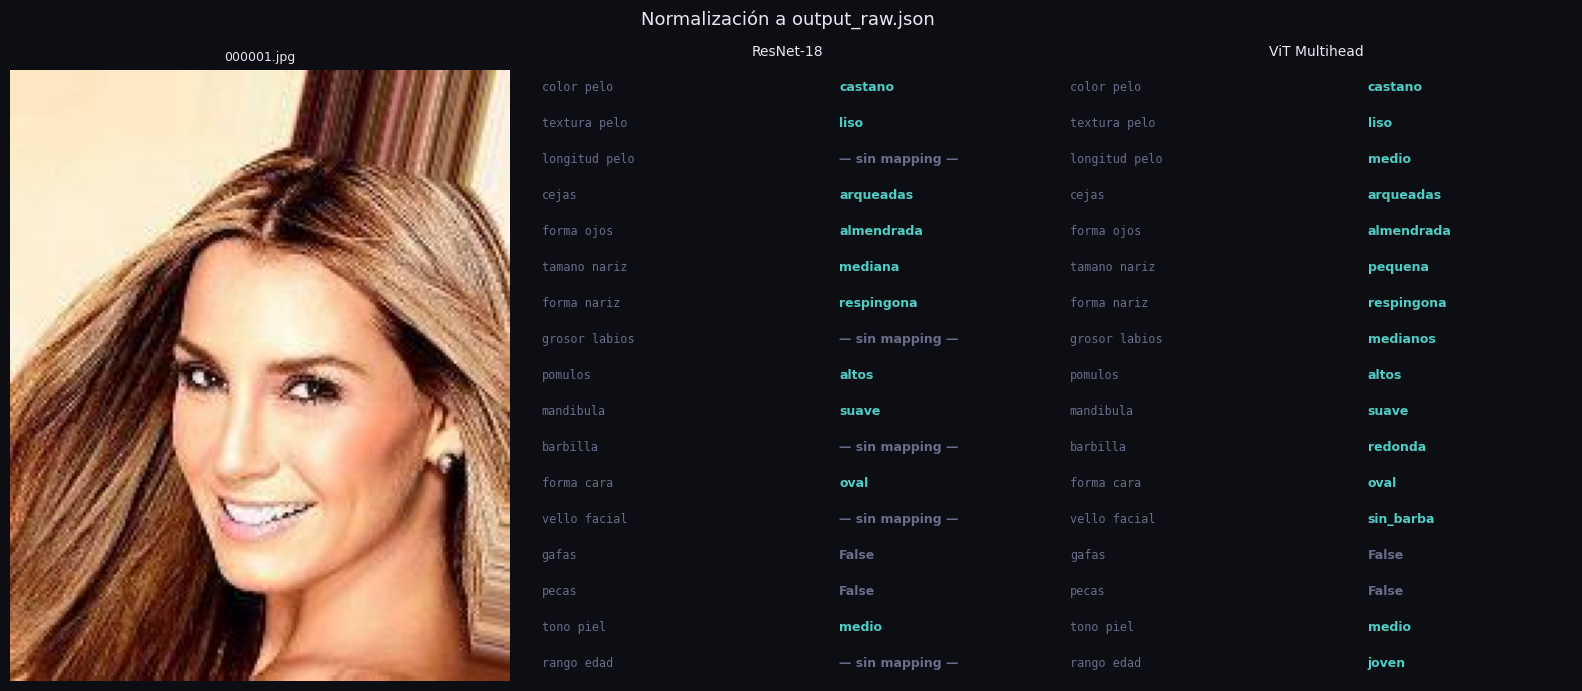


── Categorías con diferencia ──
  tamano_nariz        resnet=mediana  vit=pequena


In [5]:
# ── Comparación visual side-by-side ──────────────────────────────────────────
cats = list(CLASS_LABELS.keys())

fig, axes = plt.subplots(1, 3, figsize=(16, 7))
fig.patch.set_facecolor('#0d0d14')
fig.suptitle('Normalización a output_raw.json', color='#e8e8f0', fontsize=13)

NEGATIVE = {None, 'False', 'false'}

def plot_flags(ax, result, title):
    ax.set_facecolor('#13131f')
    ax.set_xlim(0, 1); ax.set_ylim(-0.5, len(cats) - 0.5)
    ax.axis('off')
    ax.set_title(title, color='#e8e8f0', fontsize=10, pad=10)
    for i, cat in enumerate(reversed(cats)):
        val = result.get(cat)
        val_str = str(val) if val is not None else '— sin mapping —'
        color = '#6b6b8a' if val in NEGATIVE else ('#4ecdc4' if val is not None else '#3a3a55')
        ax.text(0.02, i, cat.replace('_',' '),
                va='center', color='#6b6b8a', fontsize=8.5, fontfamily='monospace')
        ax.text(0.60, i, val_str,
                va='center', color=color, fontsize=9, fontweight='bold')
    for s in ax.spines.values(): s.set_edgecolor('#2a2a45')

# Imagen
axes[0].imshow(Image.open(TEST_IMAGE))
axes[0].set_title(TEST_IMAGE.name, color='#e8e8f0', fontsize=9)
axes[0].axis('off')

plot_flags(axes[1], normalized_resnet, 'ResNet-18')
plot_flags(axes[2], normalized_vit,    'ViT Multihead')

plt.tight_layout()
plt.show()

# Diferencias entre los dos
print('\n── Categorías con diferencia ──')
any_diff = False
for cat in cats:
    r = normalized_resnet.get(cat)
    v = normalized_vit.get(cat)
    if r is None: continue   # sin mapping ResNet
    if r != v:
        print(f'  {cat:<18}  resnet={r}  vit={v}')
        any_diff = True
if not any_diff:
    print('  (ninguna — ambos modelos coinciden en las categorías con mapping)')

In [6]:
# ── Guardar JSONs ─────────────────────────────────────────────────────────────
Path('output_resnet_flags.json').write_text(
    json.dumps(normalized_resnet, indent=2, ensure_ascii=False))
Path('output_vit_flags.json').write_text(
    json.dumps(normalized_vit, indent=2, ensure_ascii=False))

print('Guardado:')
print('  output_resnet_flags.json')
print('  output_vit_flags.json')

Guardado:
  output_resnet_flags.json
  output_vit_flags.json
